In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
#visualize
path="../data/Heart_Disease.csv"
data=pd.read_csv(path)
#result=data.plot(kind="box",sharex=False,layout=(4,4),subplots=True,figsize=(18,14))
# plt.tight_layout()
# plt.show()
# a=data.corr()
b=data.describe()
print(data.isnull().sum())
print(data['Heart Disease'].value_counts(normalize=True))
# set feature and target
x=data.drop("Heart Disease",axis=1)
y=data["Heart Disease"]

#split data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
#preprocessing
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

#
cls=SVC()
cls.fit(x_train,y_train)
y_predict=cls.predict(x_test)

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64
Heart Disease
0    0.555556
1    0.444444
Name: proportion, dtype: float64


--- TỔNG QUAN DỮ LIỆU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    int64  
dtype

C:\Users\Admin\AppData\Local\Temp\ipykernel_1524\2498757198.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Heart Disease', data=data, palette='viridis')


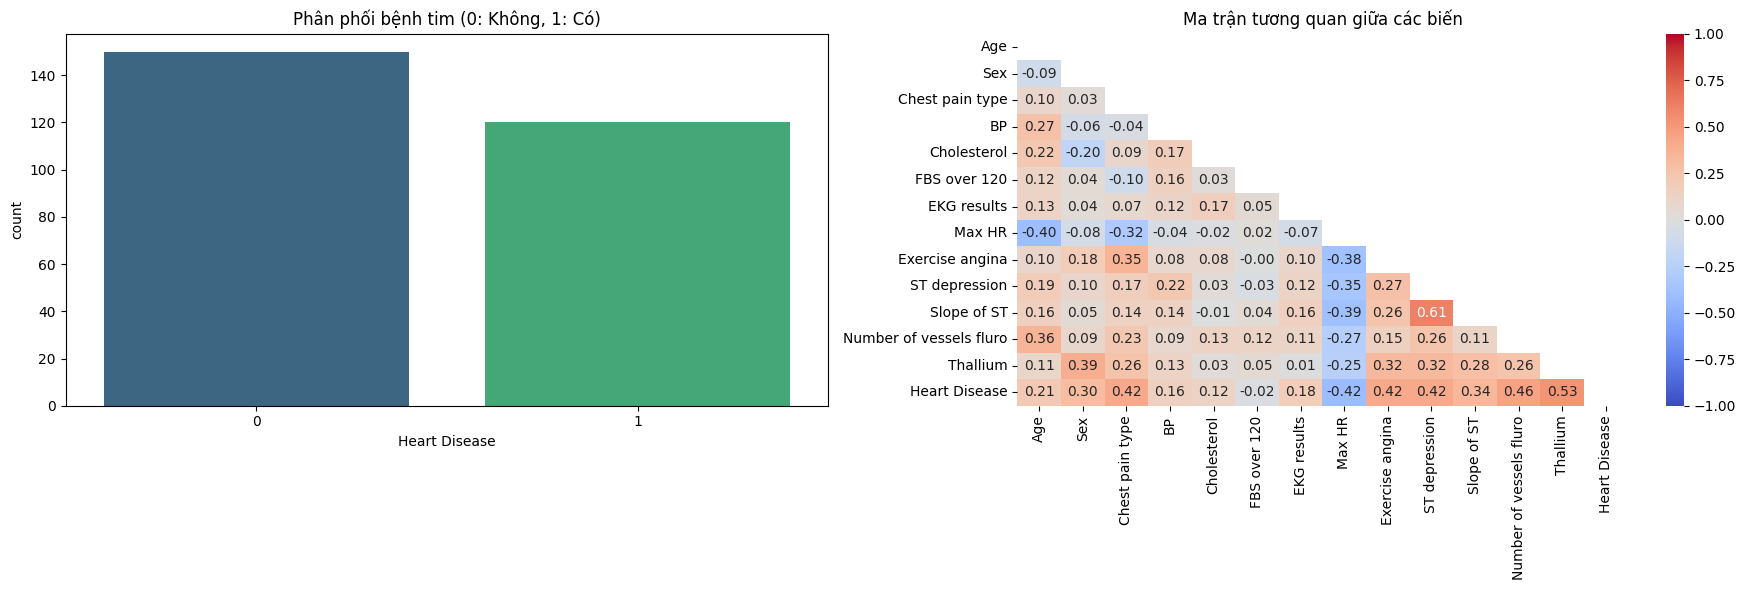

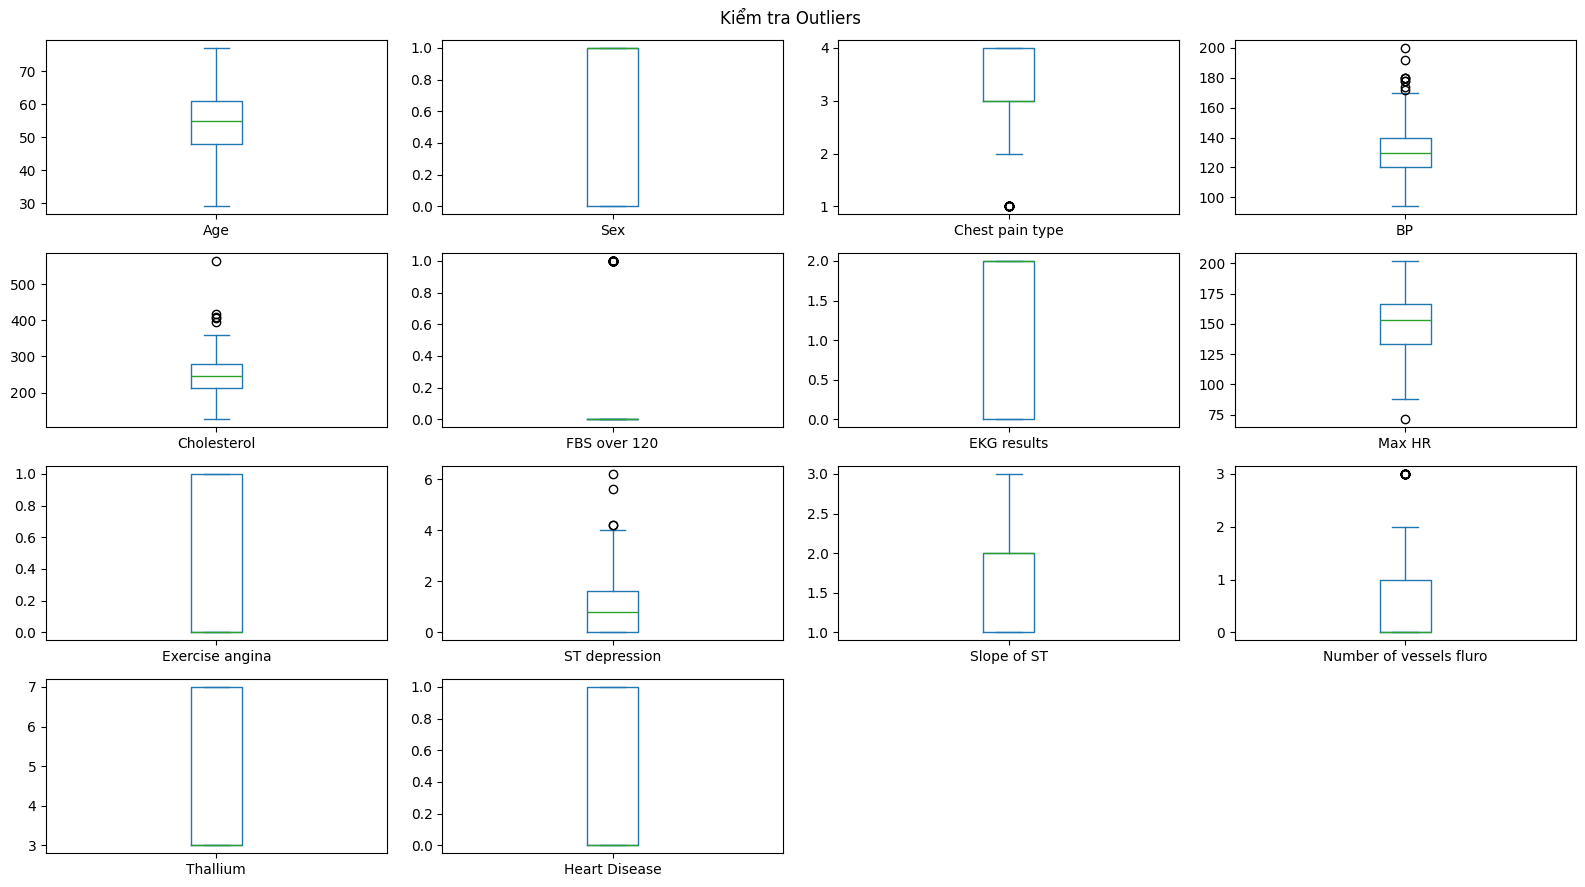

Kích thước tập Train: (216, 13)
Kích thước tập Test: (54, 13)

--- BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) ---
              precision    recall  f1-score   support

           0       0.89      0.83      0.86        30
           1       0.81      0.88      0.84        24

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.86      0.85      0.85        54


--- MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---


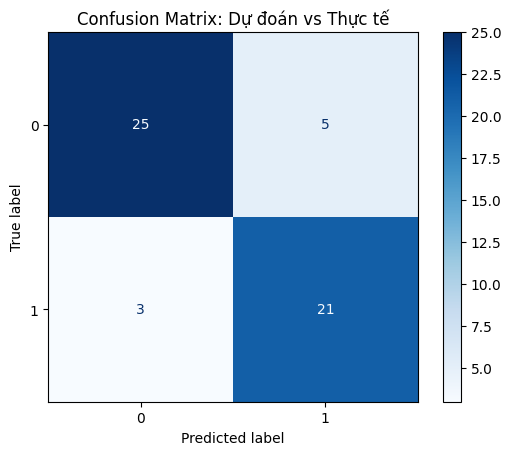

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# %% [PHẦN 0] GIẢ LẬP DỮ LIỆU (Thay thế phần này bằng pd.read_csv của bạn)
# Tạo dữ liệu giả để code có thể chạy được ngay
path="../data/Heart_Disease.csv"
data=pd.read_csv(path)# <--- Dùng dòng này của bạn

# %% [BƯỚC 1] STATISTICS & EDA (Thống kê mô tả)
print("--- TỔNG QUAN DỮ LIỆU ---")
print(data.info())
print("\n--- THỐNG KÊ MÔ TẢ ---")
print(data.describe())

# Kiểm tra dữ liệu bị thiếu (Missing values)
print("\n--- SỐ LƯỢNG MISSING VALUES ---")
print(data.isnull().sum())

# Kiểm tra cân bằng nhãn (Quan trọng với bài toán y tế)
print("\n--- TỈ LỆ NHÃN (TARGET BALANCE) ---")
print(data['Heart Disease'].value_counts(normalize=True))

# %% [BƯỚC 2] VISUALIZATION (Trực quan hóa)
plt.figure(figsize=(18, 6))

# Biểu đồ 1: Phân phối của nhãn (Target)
plt.subplot(1, 2, 1)
sns.countplot(x='Heart Disease', data=data, palette='viridis')
plt.title("Phân phối bệnh tim (0: Không, 1: Có)")

# Biểu đồ 2: Tương quan (Correlation Heatmap)
plt.subplot(1, 2, 2)
correlation = data.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool)) # Che nửa trên tam giác cho gọn
sns.heatmap(correlation, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Ma trận tương quan giữa các biến")

plt.tight_layout()
plt.show()

# Biểu đồ 3: Boxplot để xem Outlier (như code bạn đã thử)
data.plot(kind="box", subplots=True, layout=(4, 4), figsize=(16, 9), title="Kiểm tra Outliers")
plt.tight_layout()
plt.show()

# %% [BƯỚC 3] PREPROCESSING (Tiền xử lý & Chia tập tin)
# Tách Feature và Target
X = data.drop("Heart Disease", axis=1)
y = data["Heart Disease"]

# Chia train/test (Nên dùng stratify=y để đảm bảo tỉ lệ nhãn ở 2 tập như nhau)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Chuẩn hóa (Standardization)
scaler = StandardScaler()

# QUY TẮC VÀNG: Fit trên Train, Transform trên Test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Kích thước tập Train: {X_train_scaled.shape}")
print(f"Kích thước tập Test: {X_test_scaled.shape}")

# %% [BƯỚC 4] TRIỂN KHAI MÔ HÌNH & ĐÁNH GIÁ (Evaluation)
# Khởi tạo và huấn luyện
svm_model = SVC(kernel='linear', random_state=42) # Thử kernel linear cho đơn giản trước
svm_model.fit(X_train_scaled, y_train)

# Dự đoán
y_pred = svm_model.predict(X_test_scaled)

# ĐÁNH GIÁ CHUYÊN NGHIỆP
print("\n--- BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) ---")
# Thay vì print loop, dùng cái này để xem Precision, Recall, F1-Score
print(classification_report(y_test, y_pred))

print("\n--- MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Dự đoán vs Thực tế")
plt.show()